<a href="https://colab.research.google.com/github/Anees31-AI/Anees31-AI/blob/main/tumor_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from google.colab import files
uploaded=files.upload()

Saving Tumor Detection.v8i.yolov11.zip to Tumor Detection.v8i.yolov11.zip


In [11]:
import zipfile
with zipfile.ZipFile("Tumor Detection.v8i.yolov11.zip",'r') as zip_ref:
  zip_ref.extractall("TumorDetection")

#Checks Whats Inside


In [12]:
import os
for root ,dirs, files in os.walk("TumorDetection"):
  print(root)
  for f in files [:5]:
    print("└──",f)

TumorDetection
└── README.roboflow.txt
└── data.yaml
└── README.dataset.txt
TumorDetection/train
TumorDetection/train/labels
└── meningioma_446_jpg.rf.586ea523102745fbd6d7d19556a4f4a9.txt
└── meningioma_1118_jpg.rf.00df375c7507bc402d95140278e74d13.txt
└── meningioma_1148_jpg.rf.73e39019ddab5614fcc3f395e46b9055.txt
└── pituitary_977_jpg.rf.5d98843fa265f54b2682dc5c3a75e3a1.txt
└── pituitary_874_jpg.rf.363dad0f07212d570140256caa943d3a.txt
TumorDetection/train/images
└── meningioma_383_jpg.rf.fe267a92271133c9b424231cc42a4d75.jpg
└── meningioma_1076_jpg.rf.4fa57284674e5fbf07d6446ff67d0a76.jpg
└── meningioma_1282_jpg.rf.99fa3552b33841ac55cc812908286092.jpg
└── meningioma_944_jpg.rf.86b8a982d384dfff1deeaa03e63e97db.jpg
└── meningioma_294_jpg.rf.00a8bb2e998110e2e598b32410f39c36.jpg
TumorDetection/valid
TumorDetection/valid/labels
└── glioma_201_jpg.rf.a847f9af4f209d6323a0c4e4f07d63f1.txt
└── meningioma_47_jpg.rf.0d318bff47238418444d43c002c2c905.txt
└── no_tumor_535_jpg.rf.a70887aedbcf0828ad420

In [13]:
!pip install ultralytics

#Moving the extracted dataset

In [16]:
import shutil
shutil.move("TumorDetection","/content/datasets/TumorDetection")

'/content/datasets/TumorDetection'

In [18]:

from ultralytics import YOLO
#Load the model
model=YOLO("yolo11n.pt")
#Train the model
train_results=model.train(
    data="/content/datasets/TumorDetection/data.yaml", #Path to dataset
    epochs=20, #number of training epochs
    imgsz=640, #Training image size
    device='0',
)

Ultralytics 8.3.112 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=/content/datasets/TumorDetection/data.yaml, epochs=20, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=train5, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=Tru

train: Scanning /content/datasets/TumorDetection/train/labels.cache... 1370 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1370/1370 [00:00<?, ?it/s]

train: /content/datasets/TumorDetection/train/images/no_tumor_914_jpg.rf.6714544aee2bde5213fd2c366dff62aa.jpg: 1 duplicate labels removed
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 1456, len(boxes) = 1461. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 295.8±88.0 MB/s, size: 29.4 KB)


val: Scanning /content/datasets/TumorDetection/valid/labels.cache... 395 images, 0 backgrounds, 0 corrupt: 100%|██████████| 395/395 [00:00<?, ?it/s]


...

      20/20      2.82G     0.5216     0.5426      1.024         10        640: 100%|██████████| 86/86 [00:23<00:00,  3.63it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 13/13 [00:02<00:00,  4.46it/s]

                   all        395        415      0.877      0.607      0.666      0.543



20 epochs completed in 0.156 hours.
Optimizer stripped from runs/detect/train5/weights/last.pt, 5.5MB
Optimizer stripped from runs/detect/train5/weights/best.pt, 5.5MB

Validating runs/detect/train5/weights/best.pt...
Ultralytics 8.3.112 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,583,127 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 13/13 [00:06<00:00,  1.94it/s]


                   all        395        415      0.877      0.606      0.666      0.543
              NO_tumor        115        116      0.925      0.974      0.974      0.799
                glioma         30         36      0.753      0.425      0.619      0.451
            meningioma        144        148      0.951      0.892      0.954      0.833
             pituitary        106        111      0.757      0.739      0.782      0.632
space-occupying lesion-          1          4          1          0    0.00299    0.00269
Speed: 0.3ms preprocess, 3.0ms inference, 0.0ms loss, 4.2ms postprocess per image
Results saved to runs/detect/train5


In [20]:
import os
os.listdir("runs/detect")

['train2', 'train4', 'train', 'train5', 'train3']

In [22]:
for folder in['train','train2','train3','train4','train5']:
  path= f"runs/detect/{folder}/weights"
  if os.path.exists(path):
    print(f"{folder} ->", os.listdir(path))

train -> []
train2 -> []
train3 -> []
train4 -> ['last.pt', 'best.pt']
train5 -> ['last.pt', 'best.pt']



image 1/1 /content/datasets/TumorDetection/test/images/meningioma_34_jpg.rf.4a3797c5c104b735b14bbb40b91527ee.jpg: 640x640 1 meningioma, 12.3ms
Speed: 2.2ms preprocess, 12.3ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict


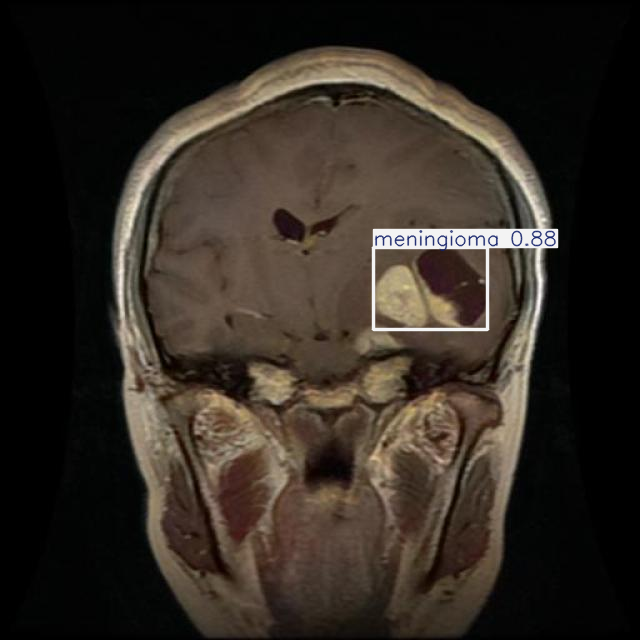

In [28]:
from ultralytics import YOLO
#Load the model
model=YOLO("runs/detect/train5/weights/best.pt")
#perform object detection on an image
results=model("/content/datasets/TumorDetection/test/images/meningioma_34_jpg.rf.4a3797c5c104b735b14bbb40b91527ee.jpg", save=True)
results[0].show()

#Code to find image path


In [29]:
import os

for root, dirs, files in os.walk("/content"):
    if "meningioma_34_jpg.rf.4a3797c5c104b735b14bbb40b91527ee.jpg" in files:
        print("✅ Found:", os.path.join(root, "meningioma_34_jpg.rf.4a3797c5c104b735b14bbb40b91527ee.jpg"))
        break

✅ Found: /content/runs/detect/predict/meningioma_34_jpg.rf.4a3797c5c104b735b14bbb40b91527ee.jpg


In [33]:
from ultralytics import YOLO
#Load the model
model=YOLO("runs/detect/train5/weights/best.pt")
#Run batch inference on a lst of images
results=model("/content/datasets/TumorDetection/test/images/meningioma_34_jpg.rf.4a3797c5c104b735b14bbb40b91527ee.jpg") #return a list of result objects
#Process result list
for result in results:
    boxes=result.boxes #Boxes object for bounding box outputs
    print(boxes)


image 1/1 /content/datasets/TumorDetection/test/images/meningioma_34_jpg.rf.4a3797c5c104b735b14bbb40b91527ee.jpg: 640x640 1 meningioma, 17.9ms
Speed: 2.7ms preprocess, 17.9ms inference, 2.8ms postprocess per image at shape (1, 3, 640, 640)
ultralytics.engine.results.Boxes object with attributes:

cls: tensor([2.], device='cuda:0')
conf: tensor([0.8797], device='cuda:0')
data: tensor([[373.5228, 247.2542, 487.3664, 329.0562,   0.8797,   2.0000]], device='cuda:0')
id: None
is_track: False
orig_shape: (640, 640)
shape: torch.Size([1, 6])
xywh: tensor([[430.4446, 288.1552, 113.8436,  81.8020]], device='cuda:0')
xywhn: tensor([[0.6726, 0.4502, 0.1779, 0.1278]], device='cuda:0')
xyxy: tensor([[373.5228, 247.2542, 487.3664, 329.0562]], device='cuda:0')
xyxyn: tensor([[0.5836, 0.3863, 0.7615, 0.5142]], device='cuda:0')


In [36]:
from ultralytics import YOLO
from ultralytics import SAM

#Load the yolo model
yolo_model=YOLO("runs/detect/train5/weights/best.pt")

#Run batch inference on a list of images
results=yolo_model("/content/datasets/TumorDetection/test/images/meningioma_34_jpg.rf.4a3797c5c104b735b14bbb40b91527ee.jpg") #Return a list of result objects
#Load the Sam model
sam_model=SAM("sam2_b.pt")
for result in results:
    class_ids=result.boxes.cls.int().tolist() #noqa
    if len(class_ids):
        boxes=result.boxes.xywhn
        sam_results=sam_model(result.orig_img,bboxes=boxes,verbose=False, save=True,device='0')


image 1/1 /content/datasets/TumorDetection/test/images/meningioma_34_jpg.rf.4a3797c5c104b735b14bbb40b91527ee.jpg: 640x640 1 meningioma, 12.3ms
Speed: 2.4ms preprocess, 12.3ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


100%|██████████| 154M/154M [00:04<00:00, 37.3MB/s]


Results saved to runs/segment/predict
